In [1]:
# === KNN REGRESIÓN: Ocupación mensual por hotel ===
import pandas as pd
import numpy as np


In [2]:
# Carga
df = pd.read_csv("data/hotel_bookings.csv")

In [3]:
# Aseguramos tipos numéricos (por si hay strings)
to_numeric_cols = [
    "lead_time","stays_in_week_nights","stays_in_weekend_nights",
    "adults","children","babies","adr",
    "total_of_special_requests"
]
for c in to_numeric_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")

In [4]:
# --- Normalizar meses (orden correcto) ---
month_order = ["January","February","March","April","May","June",
               "July","August","September","October","November","December"]
df["arrival_date_month"] = pd.Categorical(df["arrival_date_month"], categories=month_order, ordered=True)

# --- Target: ocupación mensual (conteo de reservas por hotel y mes-año) ---
# incluimos año para que no mezcle el mismo mes de años distintos
group_cols = ["hotel","arrival_date_year","arrival_date_month"]

ocupacion = (
    df.groupby(group_cols)
      .size()
      .reset_index(name="ocupacion")        # <- TARGET (conteo)
)


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_6868\42810919.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(group_cols)


In [5]:
# --- Features agregadas por hotel-mes-año ---
agg = (
    df.groupby(group_cols)
      .agg({
          "lead_time":"mean",
          "adr":"mean",
          "stays_in_week_nights":"mean",
          "stays_in_weekend_nights":"mean",
          "adults":"mean",
          "children":"mean",
          "babies":"mean",
          "total_of_special_requests":"mean"
      })
      .reset_index()
)


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_6868\2623120653.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(group_cols)


In [6]:
# Merge target + features
data = ocupacion.merge(agg, on=group_cols, how="inner")

In [7]:
# Codificar categóricas
data["hotel"] = data["hotel"].map({"City Hotel":0, "Resort Hotel":1}).astype(int)
data["month_num"] = data["arrival_date_month"].cat.codes + 1  # 1..12
# (opcional) mantener año como numérico
data["arrival_date_year"] = pd.to_numeric(data["arrival_date_year"], errors="coerce")

In [8]:
# Dataset final para el modelo
feature_cols = [
    "hotel", "arrival_date_year", "month_num",
    "lead_time","adr",
    "stays_in_week_nights","stays_in_weekend_nights",
    "adults","children","babies",
    "total_of_special_requests"
]
target = "ocupacion"

model_df = data[feature_cols + [target]].dropna().copy()

print(model_df.head())
print(model_df.shape, "filas x columnas")

    hotel  arrival_date_year  month_num   lead_time         adr  \
6       0               2015          7  180.595136   69.819170   
7       0               2015          8  113.636694   77.729198   
8       0               2015          9  113.737603  101.064472   
9       0               2015         10  102.478145   89.393113   
10      0               2015         11   57.412146   73.541862   

    stays_in_week_nights  stays_in_weekend_nights    adults  children  \
6               1.893419                 0.800429  1.910587  0.010014   
7               1.959274                 0.762500  1.893952  0.066640   
8               1.949277                 0.782658  1.780108  0.025503   
9               1.893680                 0.721796  1.745422  0.028943   
10              2.228340                 0.679352  1.553036  0.020243   

      babies  total_of_special_requests  ocupacion  
6   0.001431                   0.135193       1398  
7   0.006452                   0.352016       2480  

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [10]:
# X, y
X = model_df[feature_cols]
y = model_df[target]


In [11]:
# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [12]:
# Escalado (KNN necesita escala)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

In [13]:
# Modelo base (k=4 como punto de partida)
knn = KNeighborsRegressor(n_neighbors=4)
knn.fit(X_train_sc, y_train)

,n_neighbors,4
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [14]:
from sklearn.metrics import mean_squared_error
import numpy as np

# Predicción y métricas
y_pred = knn.predict(X_test_sc)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)  # raíz cuadrada del MSE
r2 = r2_score(y_test, y_pred)

print(f"KNN base -> R²: {r2:.3f} | RMSE: {rmse:.3f}")


KNN base -> R²: 0.544 | RMSE: 540.584


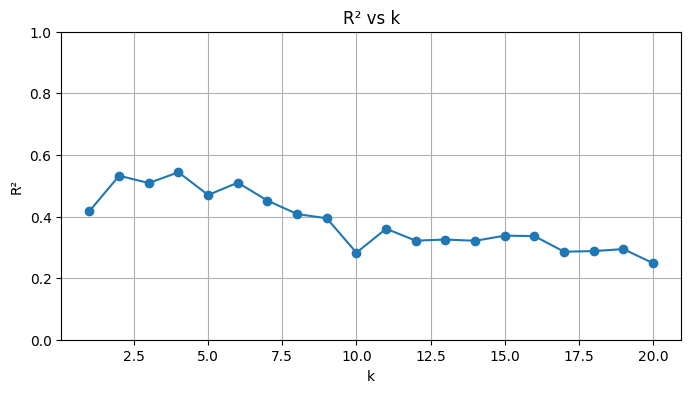

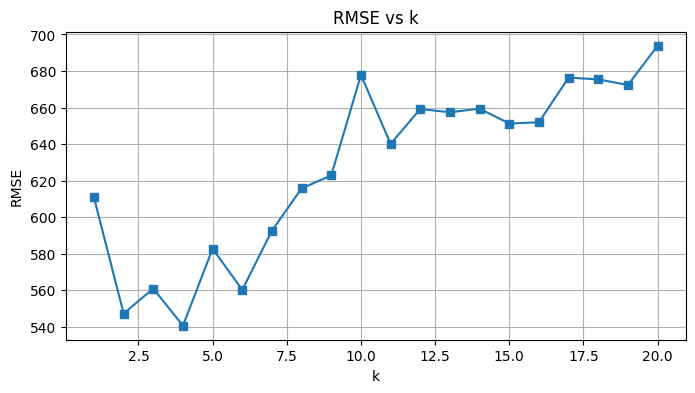

In [15]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt

r2_scores = []
rmse_scores = []
k_values = range(1, 21)

for k in k_values:
    knn = KNeighborsRegressor(n_neighbors=k)
    knn.fit(X_train_sc, y_train)
    y_pred = knn.predict(X_test_sc)
    r2_scores.append(r2_score(y_test, y_pred))
    rmse_scores.append(np.sqrt(mean_squared_error(y_test, y_pred)))

plt.figure(figsize=(8,4))
plt.plot(k_values, r2_scores, marker='o')
plt.ylim(0,1); plt.xlabel("k"); plt.ylabel("R²"); plt.title("R² vs k")
plt.grid(True); plt.show()

plt.figure(figsize=(8,4))
plt.plot(k_values, rmse_scores, marker='s')
plt.xlabel("k"); plt.ylabel("RMSE"); plt.title("RMSE vs k")
plt.grid(True); plt.show()

